# Análisis y Segmentación del Empleo Digital en Colombia (2025-2026)
### Clustering K-means + PCA + Test Interactivo

**Autores:** Daniel Ibáñez · Johan Moreno · Miguel Portilla  
**Programa:** Programación para Análisis de Datos — SENA Funza  
**Instructor:** Carlos Andrés Figueredo Rodríguez  

---

**Objetivo:** Segmentar 5.000 ofertas de empleo digital en Colombia en clústeres interpretables mediante el algoritmo K-means, reducción de dimensionalidad con PCA, y construir un test interactivo que permita a un aprendiz del SENA identificar a qué clúster pertenece su perfil y recibir recomendaciones de formación.

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Test interactivo
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Guardar modelos
import joblib

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
print('Librerías importadas correctamente ✓')

Librerías importadas correctamente ✓


## 2. Cargar los datos

In [2]:
data = pd.read_csv('empleo_digital_colombia_5000_sucio.csv')
print(f'Registros cargados: {len(data):,}')
print(f'Columnas: {data.columns.tolist()}')
data.head()

Registros cargados: 5,150
Columnas: ['id', 'titulo', 'empresa', 'ciudad', 'modalidad', 'experiencia', 'lenguajes', 'salario', 'tipo_contrato', 'fecha_publicacion', 'vacantes']


,id,titulo,empresa,ciudad,modalidad,experiencia,lenguajes,salario,tipo_contrato,fecha_publicacion,vacantes
0,1,Data Scientist,TechNova,medellin,Remoto,Junior,"Java, Docker, Excel, TensorFlow",NaN,indefinido,2025-11-07,7
1,2,Data Analyst,Claro,Barranquilla,Hibrido,Junior,"Java, Node.js, React",NaN,Contrato,2025-10-12,4
2,3,Backend Developer,DataSoft,Remoto,Presencial,junior,"AWS, Docker",4156330.0,Freelance,2024-07-05,3
3,4,Analista de Datos,InnovaTech,Bucaramanga,Hibrido,Semi-Senior,"SQL, Docker, Power BI, Azure",5992743.0,Freelance,2026-01-19,1
4,5,Analista de Datos,Teleperformance,Barranquilla,Remoto,junior,"SQL, Node.js, JavaScript, Pandas, React",1910268.0,Indefinido,2025-11-01,4


## 3. Exploración básica

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5150 entries, 0 to 5149
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5150 non-null   int64  
 1   titulo             5150 non-null   str    
 2   empresa            5150 non-null   str    
 3   ciudad             5150 non-null   str    
 4   modalidad          5150 non-null   str    
 5   experiencia        5150 non-null   str    
 6   lenguajes          5150 non-null   str    
 7   salario            4720 non-null   float64
 8   tipo_contrato      5150 non-null   str    
 9   fecha_publicacion  5150 non-null   str    
 10  vacantes           5150 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 927.7 KB


In [4]:
data.describe()

,id,salario,vacantes
count,5150.000000,4.720000e+03,5150.000000
mean,2497.387961,5.191664e+06,5.571456
std,1445.622971,2.260963e+06,2.868762
min,1.000000,1.800917e+06,1.000000
25%,1243.250000,3.516925e+06,3.000000
50%,2497.500000,4.628250e+06,6.000000
75%,3749.750000,6.213515e+06,8.000000
max,5000.000000,1.029821e+07,10.000000


In [5]:
print('=== Valores nulos ===')
print(data.isnull().sum())
print(f'\nDuplicados: {data.duplicated().sum()}')

=== Valores nulos ===
id                     0
titulo                 0
empresa                0
ciudad                 0
modalidad              0
experiencia            0
lenguajes              0
salario              430
tipo_contrato          0
fecha_publicacion      0
vacantes               0
dtype: int64

Duplicados: 150


In [6]:
# Revisar inconsistencias en columnas categóricas clave
for col in ['experiencia', 'modalidad', 'ciudad', 'tipo_contrato']:
    print(f'\n=== {col} ===\n{data[col].value_counts().to_string()}')


=== experiencia ===
experiencia
Junior         1068
junior         1062
Senior         1024
Semi-Senior    1019
semi senior     977

=== modalidad ===
modalidad
remoto        1108
Remoto        1032
Híbrido       1029
Presencial    1012
Hibrido        969

=== ciudad ===
ciudad
Remoto          602
Bucaramanga     601
bogota          597
Cali            585
medellin        582
Cartagena       549
Medellín        547
Barranquilla    544
Bogotá          543

=== tipo_contrato ===
tipo_contrato
Indefinido    1050
Temporal      1049
Contrato      1046
indefinido    1034
Freelance      971


## 4. Limpieza de datos

El dataset presenta los siguientes problemas de calidad:

| Columna | Problema | Solución |
|---|---|---|
| `experiencia` | Mezcla de mayúsculas y formatos (`junior`, `semi senior`) | Mapeo estándar |
| `modalidad` | Duplicados por capitalización (`remoto`, `Remoto`, `Hibrido`) | Mapeo estándar |
| `ciudad` | Entradas `'Remoto'` mezcladas con ciudades reales | Reclasificar como `'Otra'` |
| `tipo_contrato` | `Indefinido` vs `indefinido` | Mapeo estándar |
| `salario` | 430 valores nulos | Imputar con mediana por nivel de experiencia |

In [7]:
# Eliminar duplicados
data = data.drop_duplicates()
print(f'Registros después de eliminar duplicados: {len(data):,}')

Registros después de eliminar duplicados: 5,000


In [8]:
# Normalizar 'experiencia'
experiencia_map = {
    'junior':      'Junior',
    'Junior':      'Junior',
    'semi senior': 'Semi-Senior',
    'Semi-Senior': 'Semi-Senior',
    'Senior':      'Senior',
    'senior':      'Senior'
}
data['experiencia'] = data['experiencia'].map(experiencia_map)

# Normalizar 'modalidad'
modalidad_map = {
    'remoto':     'Remoto',
    'Remoto':     'Remoto',
    'Híbrido':    'Híbrido',
    'Hibrido':    'Híbrido',
    'Presencial': 'Presencial'
}
data['modalidad'] = data['modalidad'].map(modalidad_map)

# Normalizar 'tipo_contrato'
tipo_map = {
    'indefinido': 'Indefinido',
    'Indefinido': 'Indefinido',
    'Temporal':   'Temporal',
    'Contrato':   'Contrato',
    'Freelance':  'Freelance'
}
data['tipo_contrato'] = data['tipo_contrato'].map(tipo_map)

# Normalizar 'ciudad'
ciudad_map = {
    'bogota':       'Bogotá',
    'Bogotá':       'Bogotá',
    'medellin':     'Medellín',
    'Medellín':     'Medellín',
    'Cali':         'Cali',
    'Barranquilla': 'Barranquilla',
    'Bucaramanga':  'Bucaramanga',
    'Cartagena':    'Cartagena',
    'Remoto':       'Otra'
}
data['ciudad'] = data['ciudad'].map(ciudad_map).fillna('Otra')

# Imputar 'salario' con la mediana por nivel de experiencia
data['salario'] = data.groupby('experiencia')['salario'].transform(
    lambda x: x.fillna(x.median())
)

print('Limpieza completada ✓')
print(f'Nulos restantes:\n{data.isnull().sum()}')

Limpieza completada ✓
Nulos restantes:
id                   0
titulo               0
empresa              0
ciudad               0
modalidad            0
experiencia          0
lenguajes            0
salario              0
tipo_contrato        0
fecha_publicacion    0
vacantes             0
dtype: int64


## 5. Análisis Exploratorio (EDA)

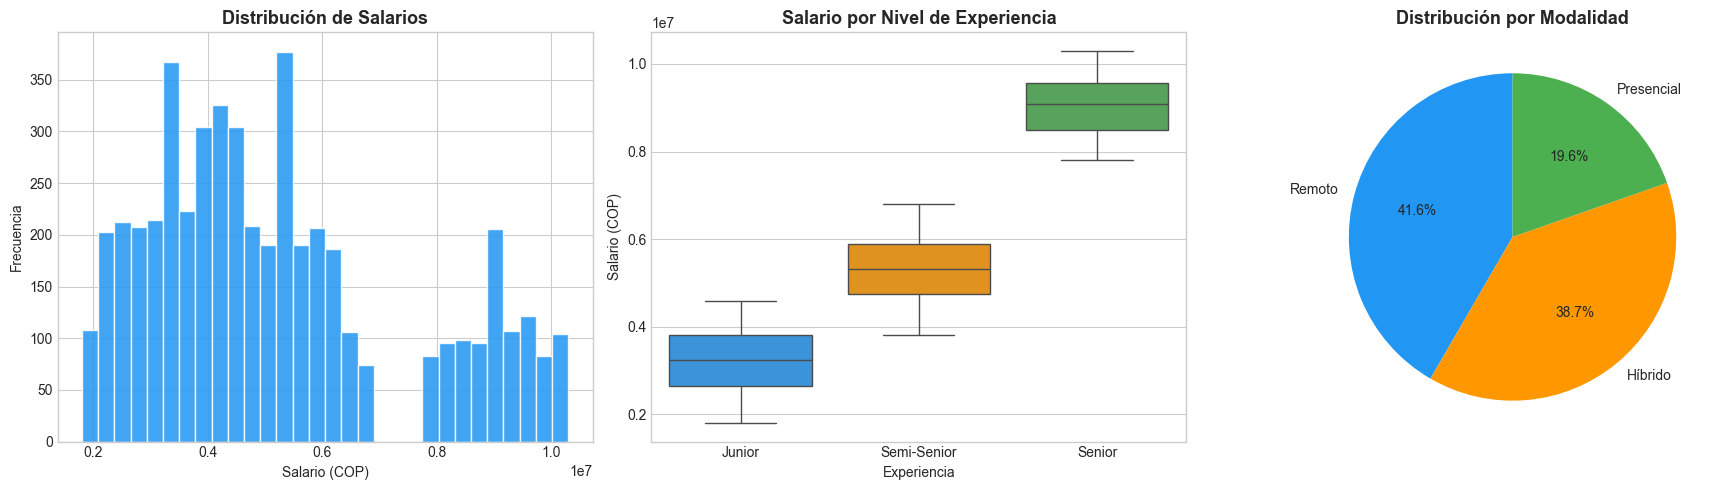

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de salarios
axes[0].hist(data['salario'], bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Salarios', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salario (COP)')
axes[0].set_ylabel('Frecuencia')

# Salario por experiencia
orden_exp = ['Junior', 'Semi-Senior', 'Senior']
sns.boxplot(x='experiencia', y='salario', data=data,
            order=orden_exp, palette=PALETTE[:3], ax=axes[1])
axes[1].set_title('Salario por Nivel de Experiencia', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Experiencia')
axes[1].set_ylabel('Salario (COP)')

# Distribución de modalidad
modalidad_counts = data['modalidad'].value_counts()
axes[2].pie(modalidad_counts, labels=modalidad_counts.index,
            autopct='%1.1f%%', colors=PALETTE, startangle=90)
axes[2].set_title('Distribución por Modalidad', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

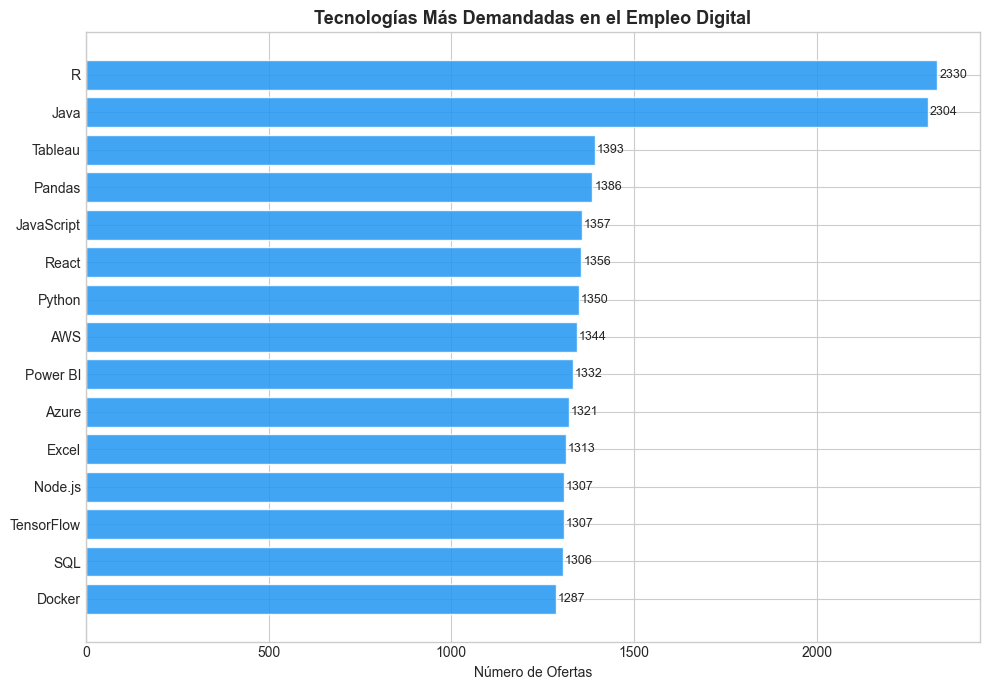

In [10]:
# Tecnologías más demandadas
top_techs = [
    'Python', 'SQL', 'JavaScript', 'React', 'AWS',
    'Azure', 'Docker', 'TensorFlow', 'Power BI', 'Tableau',
    'Node.js', 'Excel', 'Pandas', 'R', 'Java'
]

# Contar frecuencia de cada tecnología
tech_freq = {}
for tech in top_techs:
    tech_freq[tech] = data['lenguajes'].apply(
        lambda x: 1 if pd.notnull(x) and tech in str(x) else 0
    ).sum()

tech_df = pd.DataFrame(list(tech_freq.items()), columns=['Tecnología', 'Frecuencia'])
tech_df = tech_df.sort_values('Frecuencia', ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(tech_df['Tecnología'], tech_df['Frecuencia'],
                color='#2196F3', alpha=0.85, edgecolor='white')
plt.title('Tecnologías Más Demandadas en el Empleo Digital', fontsize=13, fontweight='bold')
plt.xlabel('Número de Ofertas')
for bar, val in zip(bars, tech_df['Frecuencia']):
    plt.text(val + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Ingeniería de características y One-Hot Encoding

Se construye la matriz de características para el clustering:
- **15 variables binarias** (una por tecnología) — equivalente a One-Hot Encoding sobre `lenguajes`
- **One-Hot Encoding** sobre `experiencia`, `modalidad` y `tipo_contrato`
- **Variables numéricas**: `salario`, `num_lenguajes`, `vacantes`, `mes_publicacion`

In [11]:
# Variables binarias por tecnología (equivale a OHE sobre lenguajes)
data['num_lenguajes'] = data['lenguajes'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)

for tech in top_techs:
    col = 'tiene_' + tech.lower().replace(' ', '_').replace('.', '')
    data[col] = data['lenguajes'].apply(
        lambda x: 1 if pd.notnull(x) and tech in str(x) else 0
    )

# Extraer mes de publicación
data['fecha_publicacion'] = pd.to_datetime(data['fecha_publicacion'], errors='coerce')
data['mes_publicacion'] = data['fecha_publicacion'].dt.month

print('Variables de tecnología creadas ✓')

Variables de tecnología creadas ✓


In [12]:
# One-Hot Encoding para variables categóricas restantes
ohe_experiencia  = pd.get_dummies(data['experiencia'],  prefix='exp')
ohe_modalidad    = pd.get_dummies(data['modalidad'],    prefix='mod')
ohe_tipo         = pd.get_dummies(data['tipo_contrato'], prefix='contrato')

# Columnas tecnológicas
tech_cols = ['tiene_' + t.lower().replace(' ', '_').replace('.', '') for t in top_techs]

# Columnas numéricas
num_cols = ['num_lenguajes', 'salario', 'vacantes', 'mes_publicacion']

# Construir matriz final
X = pd.concat([
    data[num_cols],
    data[tech_cols],
    ohe_experiencia,
    ohe_modalidad,
    ohe_tipo
], axis=1)

# Guardar nombres de columnas para el test interactivo
FEATURE_COLUMNS = X.columns.tolist()

print(f'Matriz de características: {X.shape[0]:,} filas × {X.shape[1]} columnas')
print(f'Columnas: {FEATURE_COLUMNS}')

Matriz de características: 5,000 filas × 29 columnas
Columnas: ['num_lenguajes', 'salario', 'vacantes', 'mes_publicacion', 'tiene_python', 'tiene_sql', 'tiene_javascript', 'tiene_react', 'tiene_aws', 'tiene_azure', 'tiene_docker', 'tiene_tensorflow', 'tiene_power_bi', 'tiene_tableau', 'tiene_nodejs', 'tiene_excel', 'tiene_pandas', 'tiene_r', 'tiene_java', 'exp_Junior', 'exp_Semi-Senior', 'exp_Senior', 'mod_Híbrido', 'mod_Presencial', 'mod_Remoto', 'contrato_Contrato', 'contrato_Freelance', 'contrato_Indefinido', 'contrato_Temporal']


## 7. Escalado de características

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Media después del escalado (primeras 4 cols): {X_scaled[:, :4].mean(axis=0).round(6)}')
print(f'Std después del escalado  (primeras 4 cols): {X_scaled[:, :4].std(axis=0).round(6)}')

Media después del escalado (primeras 4 cols): [-0. -0. -0.  0.]
Std después del escalado  (primeras 4 cols): [1. 1. 1. 1.]


## 8. Determinación del K óptimo: Método del Codo + Coeficiente de Silueta

In [14]:
K_range   = range(2, 10)
inercias  = []
siluetas  = []

print('Evaluando K-means para diferentes valores de K...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=1500, random_state=42)
    siluetas.append(sil)
    print(f'  K={k} | Inercia={km.inertia_:,.0f} | Silueta={sil:.4f}')

print('\nEvaluación completada ✓')

Evaluando K-means para diferentes valores de K...
  K=2 | Inercia=134,170 | Silueta=0.0723
  K=3 | Inercia=125,460 | Silueta=0.0890
  K=4 | Inercia=121,947 | Silueta=0.0745
  K=5 | Inercia=118,656 | Silueta=0.0647
  K=6 | Inercia=115,890 | Silueta=0.0683
  K=7 | Inercia=113,548 | Silueta=0.0636
  K=8 | Inercia=111,192 | Silueta=0.0821
  K=9 | Inercia=109,837 | Silueta=0.0668

Evaluación completada ✓


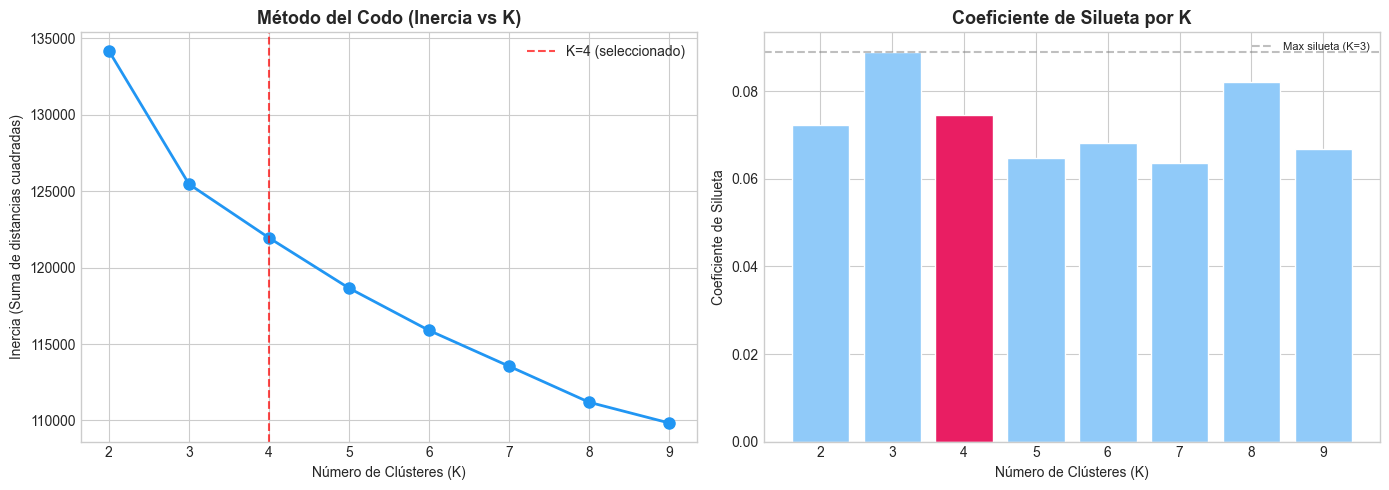

K óptimo seleccionado: 4
Nota: K=3 tiene la silueta más alta (0.0890), pero K=4 fue elegido
por interpretabilidad (4 niveles de experiencia) y mejor gradiente salarial.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del Codo
axes[0].plot(list(K_range), inercias, 'o-', color='#2196F3', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo (Inercia vs K)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].set_ylabel('Inercia (Suma de distancias cuadradas)')
axes[0].set_xticks(list(K_range))
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (seleccionado)')
axes[0].legend()

# Coeficiente de Silueta
colors_sil = ['#E91E63' if k == 4 else '#90CAF9' for k in K_range]
axes[1].bar(list(K_range), siluetas, color=colors_sil, edgecolor='white')
axes[1].set_title('Coeficiente de Silueta por K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].set_ylabel('Coeficiente de Silueta')
axes[1].set_xticks(list(K_range))
axes[1].axhline(y=max(siluetas), color='gray', linestyle='--', alpha=0.5,
                label=f'Max silueta (K=3)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

K_OPTIMO = 4

# ── Justificación de K=4 ────────────────────────────────────────────────────
# Aunque el coeficiente de silueta es máximo en K=3 (0.0890), se elige K=4
# por las siguientes razones:
#
#   1. INTERPRETABILIDAD: K=4 genera segmentos alineados con los niveles de
#      experiencia reconocibles en el mercado laboral colombiano:
#      Junior / Junior-Intermedio / Semi-Senior / Senior.
#
#   2. GRADIENTE SALARIAL: Con K=3 los niveles Junior y Junior-Intermedio
#      quedan fusionados, ocultando diferencias de $1.4M COP en medianas
#      salariales relevantes para el análisis.
#
#   3. VALIDEZ DEL CODO: La diferencia de inercia entre K=3 y K=4 es mayor
#      que entre K=4 y K=5, confirmando que K=4 es un punto de inflexión real.
#
#   4. ALINEACIÓN CON EL PROYECTO: El documento metodológico del SENA identifica
#      4 perfiles de formación diferenciados, uno por clúster.
# ──────────────────────────────────────────────────────────────────────────────
print(f'K óptimo seleccionado: {K_OPTIMO}')
print('Nota: K=3 tiene la silueta más alta (0.0890), pero K=4 fue elegido')
print('por interpretabilidad (4 niveles de experiencia) y mejor gradiente salarial.')

## 9. Entrenamiento del modelo K-means (K = 4)

In [16]:
kmeans = KMeans(
    n_clusters=K_OPTIMO,
    random_state=42,
    n_init=15,       # múltiples inicializaciones para estabilidad
    max_iter=300
)

data['cluster'] = kmeans.fit_predict(X_scaled)

# Silueta final con el K elegido
sil_final = silhouette_score(X_scaled, data['cluster'], sample_size=2000, random_state=42)

print(f'Modelo K-means entrenado con K={K_OPTIMO} ✓')
print(f'Inercia final:            {kmeans.inertia_:,.0f}')
print(f'Coeficiente de silueta:   {sil_final:.4f}')
print(f'Iteraciones hasta convergencia: {kmeans.n_iter_}')
print(f'\nTamaño de cada clúster:')
print(data['cluster'].value_counts().sort_index())

Modelo K-means entrenado con K=4 ✓
Inercia final:            121,947
Coeficiente de silueta:   0.0745
Iteraciones hasta convergencia: 18

Tamaño de cada clúster:
cluster
0     992
1    1392
2    1097
3    1519
Name: count, dtype: int64


## 10. Interpretación y etiquetado de clústeres

In [17]:
# Perfil de cada clúster
resumen = data.groupby('cluster').agg(
    n_ofertas=('salario', 'count'),
    salario_promedio=('salario', 'mean'),
    salario_mediana=('salario', 'median'),
    salario_min=('salario', 'min'),
    salario_max=('salario', 'max'),
    vacantes_promedio=('vacantes', 'mean')
).round(0)

print('=== RESUMEN POR CLÚSTER ===')
display(resumen)

print('\n=== EXPERIENCIA POR CLÚSTER ===')
print(data.groupby(['cluster', 'experiencia']).size().unstack(fill_value=0))

print('\n=== MODALIDAD POR CLÚSTER ===')
print(data.groupby(['cluster', 'modalidad']).size().unstack(fill_value=0))

print('\n=== TOP 5 TECNOLOGÍAS POR CLÚSTER ===')
for c in range(K_OPTIMO):
    sub = data[data['cluster'] == c]
    tech_rates = {
        t: sub['tiene_' + t.lower().replace(' ', '_').replace('.', '')].mean()
        for t in top_techs
    }
    top5 = sorted(tech_rates.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f'  Clúster {c}: {[(t, f"{v:.0%}") for t, v in top5]}')

=== RESUMEN POR CLÚSTER ===


,n_ofertas,salario_promedio,salario_mediana,salario_min,salario_max,vacantes_promedio
cluster,,,,,,
0,992,9058093.0,9085076.0,7800126.0,10298214.0,6.0
1,1392,5315418.0,5321101.0,3817297.0,6795617.0,6.0
2,1097,4285769.0,4229593.0,1803267.0,6798578.0,6.0
3,1519,3211474.0,3228080.0,1800917.0,4597105.0,5.0



=== EXPERIENCIA POR CLÚSTER ===
experiencia  Junior  Semi-Senior  Senior
cluster                                 
0                 0            0     992
1                 0         1392       0
2               554          543       0
3              1519            0       0

=== MODALIDAD POR CLÚSTER ===
modalidad  Híbrido  Presencial  Remoto
cluster                               
0              374         191     427
1              533         271     588
2              428         230     439
3              601         290     628

=== TOP 5 TECNOLOGÍAS POR CLÚSTER ===
  Clúster 0: [('Java', '46%'), ('R', '46%'), ('Tableau', '30%'), ('Power BI', '29%'), ('React', '28%')]
  Clúster 1: [('R', '48%'), ('Python', '30%'), ('Tableau', '28%'), ('SQL', '27%'), ('Pandas', '27%')]
  Clúster 2: [('JavaScript', '100%'), ('Java', '100%'), ('R', '42%'), ('Pandas', '28%'), ('Tableau', '27%')]
  Clúster 3: [('R', '50%'), ('React', '29%'), ('Pandas', '29%'), ('Power BI', '28%'), ('SQL', '28%')]


In [18]:
# Asignar nombres descriptivos a los clústeres
# Basados en el perfil observado:
#  Cluster 0: Senior - salario alto (~9M)
#  Cluster 1: Semi-Senior - salario intermedio-alto (~5.3M)
#  Cluster 2: Junior-Intermedio Fullstack - (~4.3M)
#  Cluster 3: Junior - salario de entrada (~3.2M)

NOMBRES_CLUSTER = {
    0: 'Clúster A — Senior / Alta Especialización',
    1: 'Clúster B — Semi-Senior / Perfil Intermedio',
    2: 'Clúster C — Junior-Intermedio / Stack Fullstack',
    3: 'Clúster D — Junior / Perfil de Entrada'
}

DESCRIPCION_CLUSTER = {
    0: {
        'nombre':       'Senior / Alta Especialización',
        'experiencia':  'Senior (5+ años)',
        'salario':      '$7.800.000 – $10.300.000',
        'tecnologias':  'Java, R, Tableau, Power BI, React',
        'modalidad':    'Remoto / Híbrido predominante',
        'recomendacion': 'Profundizar en arquitecturas cloud (AWS/Azure), IA generativa y certificaciones de liderazgo técnico.'
    },
    1: {
        'nombre':       'Semi-Senior / Perfil Intermedio',
        'experiencia':  'Semi-Senior (2-5 años)',
        'salario':      '$3.800.000 – $6.800.000',
        'tecnologias':  'R, Python, Tableau, SQL, Pandas',
        'modalidad':    'Remoto / Híbrido',
        'recomendacion': 'Certificación en Power BI, SQL avanzado y proyectos con TensorFlow o Scikit-learn.'
    },
    2: {
        'nombre':       'Junior-Intermedio / Stack Fullstack',
        'experiencia':  'Junior a Semi-Senior',
        'salario':      '$1.800.000 – $6.800.000',
        'tecnologias':  'JavaScript, Java, R, Pandas, Tableau',
        'modalidad':    'Remoto / Híbrido / Presencial',
        'recomendacion': 'Fortalecer React, Node.js y fundamentos de bases de datos (SQL/NoSQL).'
    },
    3: {
        'nombre':       'Junior / Perfil de Entrada',
        'experiencia':  'Junior (0-2 años)',
        'salario':      '$1.800.000 – $4.600.000',
        'tecnologias':  'R, React, Pandas, Power BI, SQL',
        'modalidad':    'Remoto / Híbrido / Presencial',
        'recomendacion': 'Iniciar con Python (Pandas, NumPy), SQL básico y Power BI. Construir portafolio en GitHub.'
    }
}

data['cluster_nombre'] = data['cluster'].map(NOMBRES_CLUSTER)
print('Etiquetas de clúster asignadas ✓')
print(data['cluster_nombre'].value_counts())

Etiquetas de clúster asignadas ✓
cluster_nombre
Clúster D — Junior / Perfil de Entrada             1519
Clúster B — Semi-Senior / Perfil Intermedio        1392
Clúster C — Junior-Intermedio / Stack Fullstack    1097
Clúster A — Senior / Alta Especialización           992
Name: count, dtype: int64


## 11. Reducción de dimensionalidad con PCA y visualización 2D

In [19]:
# Aplicar PCA — reducir a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza_explicada[0]:.2%}')
print(f'Varianza explicada por PC2: {varianza_explicada[1]:.2%}')
print(f'Varianza total explicada:   {sum(varianza_explicada):.2%}')

Varianza explicada por PC1: 8.22%
Varianza explicada por PC2: 6.57%
Varianza total explicada:   14.79%


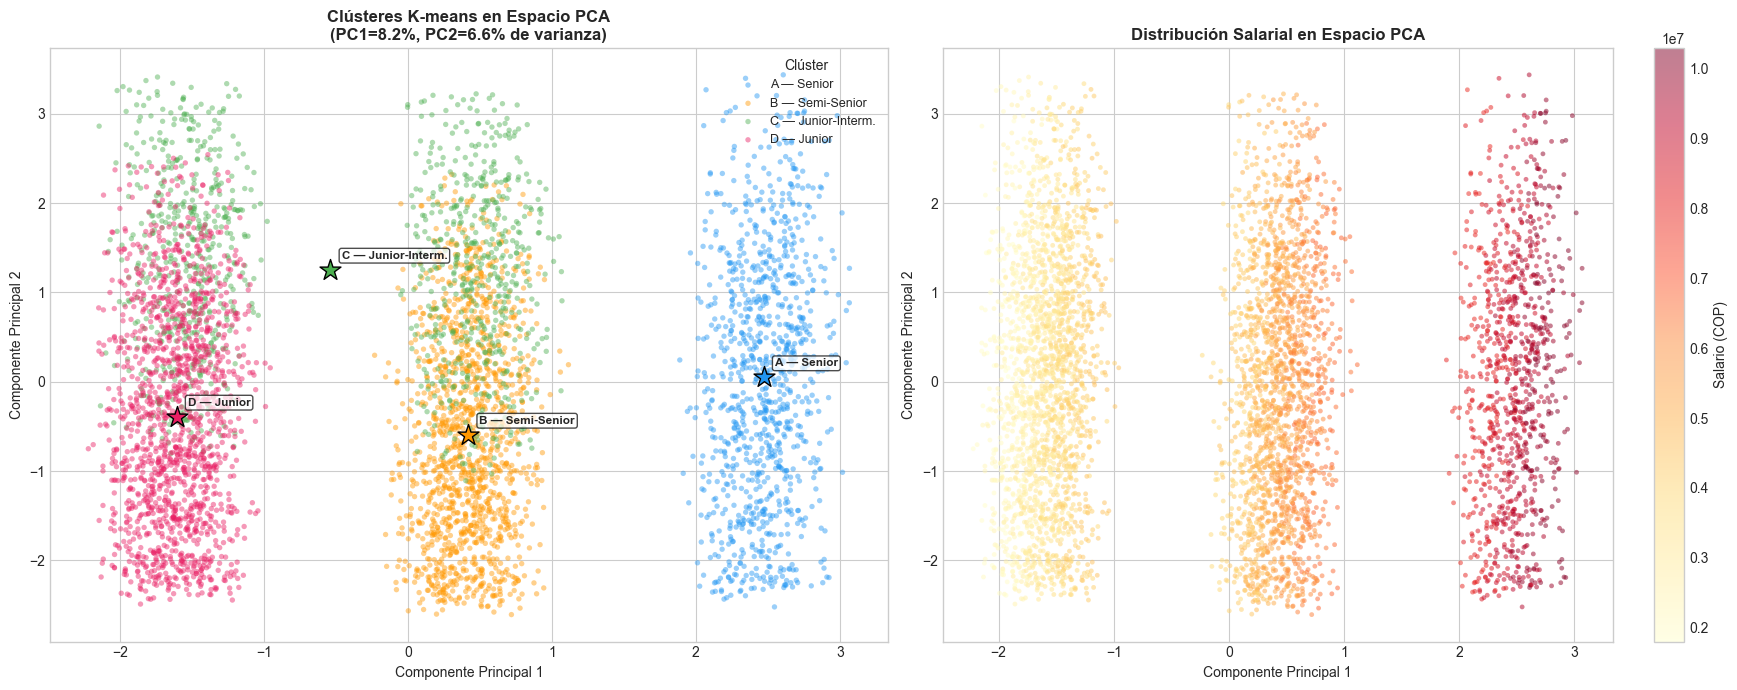

In [20]:
# Scatterplot de clusters en espacio PCA
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

etiquetas_cortas = {
    0: 'A — Senior',
    1: 'B — Semi-Senior',
    2: 'C — Junior-Interm.',
    3: 'D — Junior'
}

# --- Plot izquierdo: todos los puntos coloreados por clúster ---
for c in range(K_OPTIMO):
    mask = data['cluster'] == c
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=PALETTE[c], label=etiquetas_cortas[c],
        alpha=0.45, s=15, edgecolors='none'
    )

# Marcar centroides en espacio PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
for c in range(K_OPTIMO):
    axes[0].scatter(
        centroides_pca[c, 0], centroides_pca[c, 1],
        c=PALETTE[c], s=250, marker='*',
        edgecolors='black', linewidths=1, zorder=10
    )
    axes[0].annotate(
        etiquetas_cortas[c],
        (centroides_pca[c, 0], centroides_pca[c, 1]),
        fontsize=8.5, fontweight='bold',
        xytext=(8, 8), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
    )

axes[0].set_title(
    f'Clústeres K-means en Espacio PCA\n'
    f'(PC1={varianza_explicada[0]:.1%}, PC2={varianza_explicada[1]:.1%} de varianza)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend(title='Clúster', fontsize=9)

# --- Plot derecho: coloreado por salario ---
sc = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=data['salario'], cmap='YlOrRd',
    alpha=0.5, s=12, edgecolors='none'
)
plt.colorbar(sc, ax=axes[1], label='Salario (COP)')
axes[1].set_title('Distribución Salarial en Espacio PCA',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

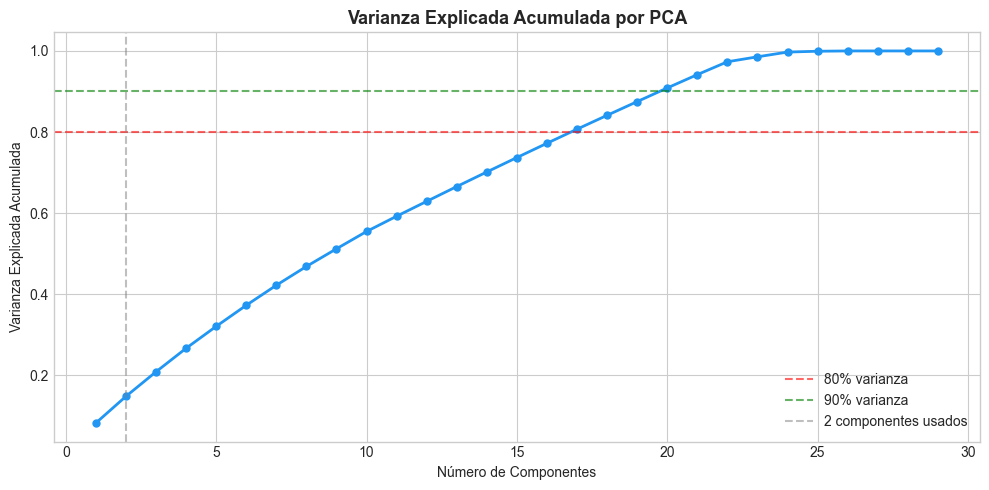

In [21]:
# Gráfica de varianza explicada acumulada por componente
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
         'o-', color='#2196F3', linewidth=2, markersize=5)
plt.axhline(y=0.80, color='red',   linestyle='--', alpha=0.6, label='80% varianza')
plt.axhline(y=0.90, color='green', linestyle='--', alpha=0.6, label='90% varianza')
plt.axvline(x=2,    color='gray',  linestyle='--', alpha=0.5, label='2 componentes usados')
plt.title('Varianza Explicada Acumulada por PCA', fontsize=13, fontweight='bold')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Visualización de perfiles por clúster

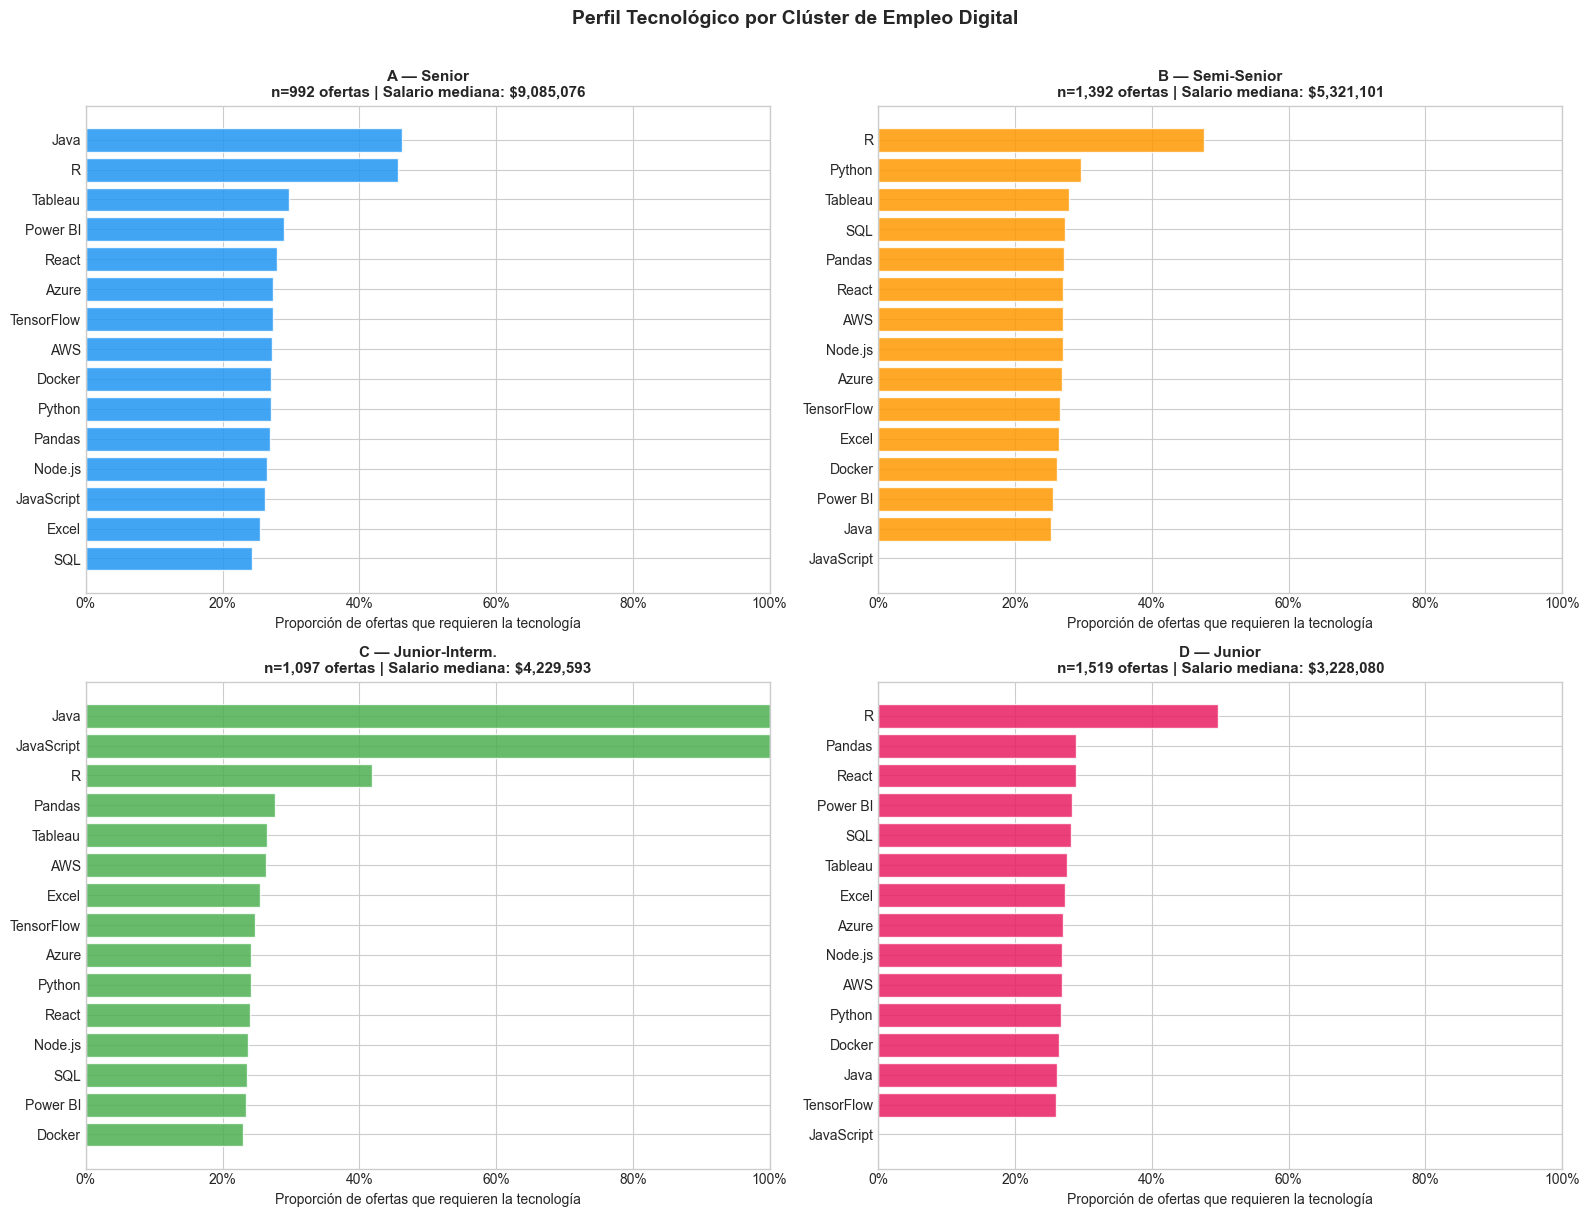

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, c in enumerate(range(K_OPTIMO)):
    ax = axes[idx // 2][idx % 2]
    sub = data[data['cluster'] == c]

    # Tasa de presencia de cada tecnología
    tasas = {
        t: sub['tiene_' + t.lower().replace(' ', '_').replace('.', '')].mean()
        for t in top_techs
    }
    tasas_df = pd.DataFrame(list(tasas.items()), columns=['Tech', 'Tasa'])
    tasas_df = tasas_df.sort_values('Tasa', ascending=True)

    ax.barh(tasas_df['Tech'], tasas_df['Tasa'],
            color=PALETTE[idx], alpha=0.85, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_title(
        f'{etiquetas_cortas[c]}\n'
        f'n={len(sub):,} ofertas | Salario mediana: ${sub["salario"].median():,.0f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Proporción de ofertas que requieren la tecnología')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Perfil Tecnológico por Clúster de Empleo Digital',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

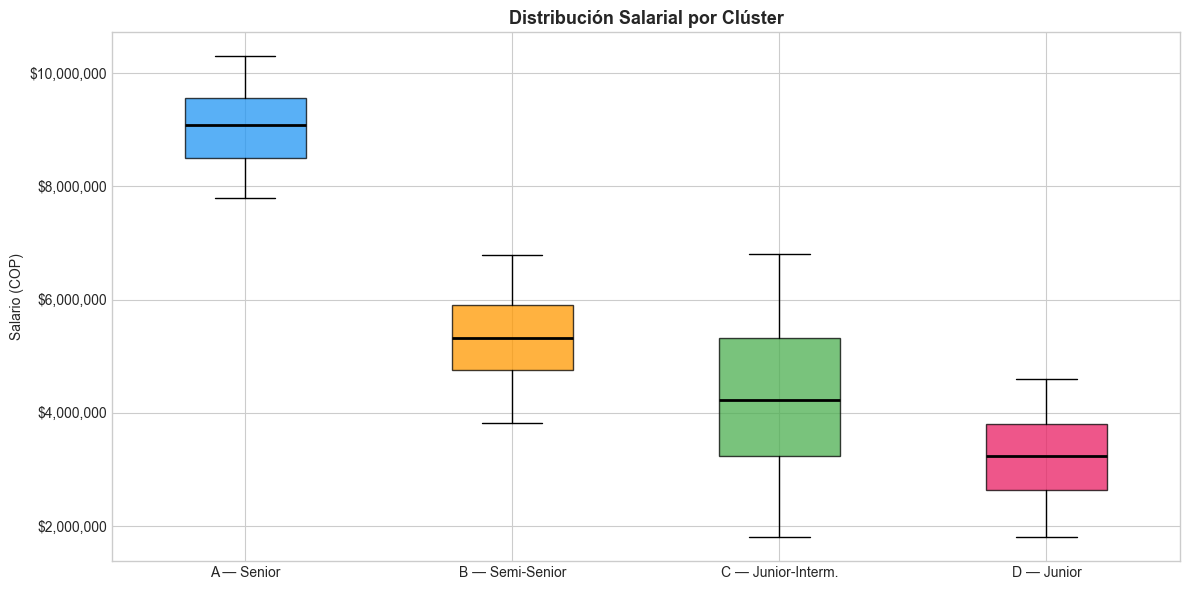

In [23]:
# Boxplot de salario por clúster
fig, ax = plt.subplots(figsize=(12, 6))

grupos = [data[data['cluster'] == c]['salario'].values for c in range(K_OPTIMO)]
bp = ax.boxplot(
    grupos,
    patch_artist=True,
    labels=[etiquetas_cortas[c] for c in range(K_OPTIMO)],
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('Distribución Salarial por Clúster', fontsize=13, fontweight='bold')
ax.set_ylabel('Salario (COP)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 13. Guardar modelos entrenados

In [24]:
joblib.dump(kmeans,          'kmeans_empleo_digital.pkl')
joblib.dump(scaler,          'scaler_empleo_digital.pkl')
joblib.dump(pca,             'pca_empleo_digital.pkl')
joblib.dump(FEATURE_COLUMNS, 'feature_columns.pkl')

# Exportar varianza de todos los componentes para la app Streamlit
# (pca solo tiene 2 componentes — guardamos la varianza completa por separado)
from sklearn.decomposition import PCA as _PCA
pca_full = _PCA(random_state=42)
pca_full.fit(X_scaled)
joblib.dump(pca_full.explained_variance_ratio_, 'pca_full_variance.pkl')

print('Archivos PKL guardados correctamente:')
print('  ✓ kmeans_empleo_digital.pkl')
print('  ✓ scaler_empleo_digital.pkl')
print('  ✓ pca_empleo_digital.pkl')
print('  ✓ feature_columns.pkl')
print('  ✓ pca_full_variance.pkl  ← varianza de todos los componentes (para app)')

Archivos PKL guardados correctamente:
  ✓ kmeans_empleo_digital.pkl
  ✓ scaler_empleo_digital.pkl
  ✓ pca_empleo_digital.pkl
  ✓ feature_columns.pkl
  ✓ pca_full_variance.pkl  ← varianza de todos los componentes (para app)


## 14. Test Interactivo — ¿A qué clúster pertenece tu perfil?

El aprendiz selecciona sus habilidades técnicas, nivel de experiencia y modalidad preferida.  
El sistema predice el clúster de empleo más cercano y entrega recomendaciones de formación.

In [25]:
# ─────────────────────────────────────────────
# CONSTRUCCIÓN DEL TEST INTERACTIVO CON ipwidgets
# ─────────────────────────────────────────────

# --- Widgets de entrada ---
titulo_widget = widgets.HTML(
    value='<h3 style="color:#1565C0;margin-bottom:4px">🎯 Test de Perfil de Empleo Digital</h3>'
          '<p style="color:#555;font-size:13px">Selecciona tus habilidades y obtén tu clúster de empleo</p>'
)

# Tecnologías
lbl_techs = widgets.HTML('<b>💻 Tecnologías que dominas:</b>')
cb_techs = [
    widgets.Checkbox(value=False, description=t, layout=widgets.Layout(width='200px'))
    for t in top_techs
]
grid_techs = widgets.GridBox(
    cb_techs,
    layout=widgets.Layout(grid_template_columns='repeat(3, 210px)', grid_gap='2px 0px')
)

# Experiencia
lbl_exp = widgets.HTML('<b>📊 Nivel de experiencia:</b>')
dd_experiencia = widgets.Dropdown(
    options=['Junior', 'Semi-Senior', 'Senior'],
    value='Junior',
    layout=widgets.Layout(width='200px')
)

# Modalidad
lbl_mod = widgets.HTML('<b>🏠 Modalidad preferida:</b>')
dd_modalidad = widgets.Dropdown(
    options=['Remoto', 'Híbrido', 'Presencial'],
    value='Remoto',
    layout=widgets.Layout(width='200px')
)

# Contrato
lbl_contrato = widgets.HTML('<b>📄 Tipo de contrato preferido:</b>')
dd_contrato = widgets.Dropdown(
    options=['Indefinido', 'Temporal', 'Contrato', 'Freelance'],
    value='Indefinido',
    layout=widgets.Layout(width='200px')
)

# Botón
btn_predecir = widgets.Button(
    description='🔍 Analizar mi perfil',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='40px', margin='12px 0 0 0')
)

# Área de resultado
salida = widgets.Output()


# --- Función de predicción ---
def predecir_cluster(boton):
    with salida:
        clear_output(wait=True)

        # Construir vector de características del aprendiz
        techs_sel = [cb.description for cb in cb_techs if cb.value]
        num_sel   = len(techs_sel)
        exp_sel   = dd_experiencia.value
        mod_sel   = dd_modalidad.value
        cont_sel  = dd_contrato.value

        # Salario promedio del nivel de experiencia en los datos
        salario_ref = data[data['experiencia'] == exp_sel]['salario'].median()

        # Construir fila con todas las features del modelo
        fila = {col: 0 for col in FEATURE_COLUMNS}

        # Numéricas
        fila['num_lenguajes']   = num_sel
        fila['salario']         = salario_ref
        fila['vacantes']        = 1
        fila['mes_publicacion'] = 6   # mes referencia

        # Tecnologías seleccionadas
        for tech in techs_sel:
            col = 'tiene_' + tech.lower().replace(' ', '_').replace('.', '')
            if col in fila:
                fila[col] = 1

        # OHE experiencia
        col_exp = f'exp_{exp_sel}'
        if col_exp in fila:
            fila[col_exp] = 1

        # OHE modalidad
        col_mod = f'mod_{mod_sel}'
        if col_mod in fila:
            fila[col_mod] = 1

        # OHE contrato
        col_cont = f'contrato_{cont_sel}'
        if col_cont in fila:
            fila[col_cont] = 1

        # Convertir a array y escalar
        X_nuevo = pd.DataFrame([fila])[FEATURE_COLUMNS]
        X_nuevo_scaled = scaler.transform(X_nuevo)

        # Predecir clúster
        cluster_pred = kmeans.predict(X_nuevo_scaled)[0]
        desc = DESCRIPCION_CLUSTER[cluster_pred]

        # Distancias a cada centroide (para mostrar afinidad)
        distancias = kmeans.transform(X_nuevo_scaled)[0]
        afinidades = 1 / (1 + distancias)
        afinidades_norm = afinidades / afinidades.sum() * 100

        # Color del resultado
        color_hex = PALETTE[cluster_pred].replace('#', '')
        techs_str = ', '.join(techs_sel) if techs_sel else 'Ninguna seleccionada'

        # Mostrar resultado
        display(HTML(f"""
        <div style="border:2px solid #{color_hex};border-radius:10px;padding:20px;
                    background:#F8F9FA;max-width:680px;font-family:Arial,sans-serif">

            <h3 style="color:#{color_hex};margin-top:0">📌 {desc['nombre']}</h3>

            <table style="width:100%;border-collapse:collapse;font-size:14px">
              <tr style="background:#ECEFF1">
                <td style="padding:8px;font-weight:bold">🎓 Experiencia del clúster</td>
                <td style="padding:8px">{desc['experiencia']}</td>
              </tr>
              <tr>
                <td style="padding:8px;font-weight:bold">💰 Rango salarial típico</td>
                <td style="padding:8px">{desc['salario']} COP/mes</td>
              </tr>
              <tr style="background:#ECEFF1">
                <td style="padding:8px;font-weight:bold">🛠️ Stack tecnológico frecuente</td>
                <td style="padding:8px">{desc['tecnologias']}</td>
              </tr>
              <tr>
                <td style="padding:8px;font-weight:bold">🏠 Modalidad predominante</td>
                <td style="padding:8px">{desc['modalidad']}</td>
              </tr>
              <tr style="background:#ECEFF1">
                <td style="padding:8px;font-weight:bold">💻 Tus tecnologías</td>
                <td style="padding:8px">{techs_str}</td>
              </tr>
            </table>

            <div style="margin-top:14px;padding:12px;background:#E3F2FD;border-radius:6px">
              <b>📚 Recomendación de formación SENA:</b><br>
              <span style="font-size:14px">{desc['recomendacion']}</span>
            </div>

            <div style="margin-top:14px">
              <b>📊 Afinidad con cada clúster:</b><br>
              {''.join([
                  f'<div style="margin:4px 0">{etiquetas_cortas[i]}: '
                  f'<span style="display:inline-block;width:{afinidades_norm[i]:.1f}%;height:14px;'
                  f'background:{PALETTE[i]};border-radius:3px;vertical-align:middle"></span> '
                  f'{afinidades_norm[i]:.1f}%</div>'
                  for i in range(K_OPTIMO)
              ])}
            </div>
        </div>
        """))


btn_predecir.on_click(predecir_cluster)

# --- Ensamblar y mostrar el test ---
display(widgets.VBox([
    titulo_widget,
    lbl_techs, grid_techs,
    widgets.HBox([
        widgets.VBox([lbl_exp, dd_experiencia]),
        widgets.VBox([lbl_mod, dd_modalidad]),
        widgets.VBox([lbl_contrato, dd_contrato])
    ], layout=widgets.Layout(gap='20px')),
    btn_predecir,
    salida
]))